In [1]:
using Revise
includet("world.jl")
includet("ParetoRRTStar.jl")
includet("ParetoPlanner.jl")

In [12]:
using Random
Random.seed!(1337)
using StaticArrays
using .World
domain = (@SVector[0.0, 0.0, 0.0], @SVector[100, 100, 2*pi])
goal = @SVector [90.0, 90.0, 0.0] # x, y, yaw
start = @SVector [10.0, 10.0, 0.0] # x, y, yaw

# can add unsafe zones here
# zone1 = World.Circle(@SVector[95.0, 125.0],30.0)
# zone4 = World.Circle(@SVector[100.0, 100.0],50.0)
# zone5 = World.Circle(@SVector[40.0, 110.0],20.0)
# zone2 = World.Rectangle(@SVector[95.0, 135.0], 80.0, 30.0, -2pi/5)
# zone3 = World.Rectangle(@SVector[80.0, 30.0], 40.0, 10.0, pi/4)
unsafe_zones = World.AbstractUnsafeZone[]


P = ParetoPlannerProblem(domain = domain, unsafe_zones = unsafe_zones)
nodes = [ ParetoRRTStar.Node(start, ParetoRRTStar.ParetoParent{2,Float64}[])]

max_iter = 200
@time ParetoRRTStar.rrt_star!(P, nodes, max_iter)



iter: 1, new node: 2, pareto parents: 1
iter: 2, new node: 3, pareto parents: 1
iter: 3, new node: 4, pareto parents: 1
iter: 4, new node: 5, pareto parents: 1
iter: 5, new node: 6, pareto parents: 1
iter: 6, new node: 7, pareto parents: 1
iter: 7, new node: 8, pareto parents: 3
iter: 8, new node: 9, pareto parents: 1
iter: 9, new node: 10, pareto parents: 1
iter: 10, new node: 11, pareto parents: 2
iter: 11, new node: 12, pareto parents: 1
iter: 12, new node: 13, pareto parents: 3
iter: 13, new node: 14, pareto parents: 2
iter: 14, new node: 15, pareto parents: 1
iter: 15, new node: 16, pareto parents: 1
iter: 16, new node: 17, pareto parents: 1
iter: 17, new node: 18, pareto parents: 1
iter: 18, new node: 19, pareto parents: 1
iter: 19, new node: 20, pareto parents: 3
iter: 20, new node: 21, pareto parents: 1
iter: 21, new node: 22, pareto parents: 1
iter: 22, new node: 23, pareto parents: 3
iter: 23, new node: 24, pareto parents: 2
iter: 24, new node: 25, pareto parents: 2
iter: 25,

In [13]:
using LinearAlgebra
goal_found = false
min_dist = Inf
min_node = 0
for i in 1:length(nodes)
    n = nodes[i]
    if norm(n.state[1:2] - goal[1:2]) < min_dist
        min_dist = norm(n.state[1:2] - goal[1:2])
        min_node = i
    end
end

pareto_front = ParetoRRTStar.pareto_front_costs(min_node, nodes)





149-element Vector{SVector{2, Float64}}:
 [113.92807292463624, 25.97098911648782]
 [113.58188965793696, 40.20321270274355]
 [113.77933780118565, 31.14178377460653]
 [112.47949760775619, 34.72241354090603]
 [112.68938003853035, 30.46822526662154]
 [112.35301445893776, 43.43796626447222]
 [114.57290543058551, 19.807731065294227]
 [114.22672216388622, 34.039954651549955]
 [114.42417030713491, 24.978525723412936]
 [113.12433011370547, 28.559155489712445]
 ⋮
 [108.394851934229, 50.58447004865475]
 [107.09501174079954, 54.16509981495426]
 [107.3048941715737, 49.910911540669765]
 [108.78060308233357, 33.951579926061626]
 [108.43441981563429, 48.18380351231736]
 [108.63186795888298, 39.122374584180335]
 [107.33202776545352, 42.703004350479844]
 [107.54191019622768, 38.44881607619534]
 [107.2055446166351, 51.418557074046035]

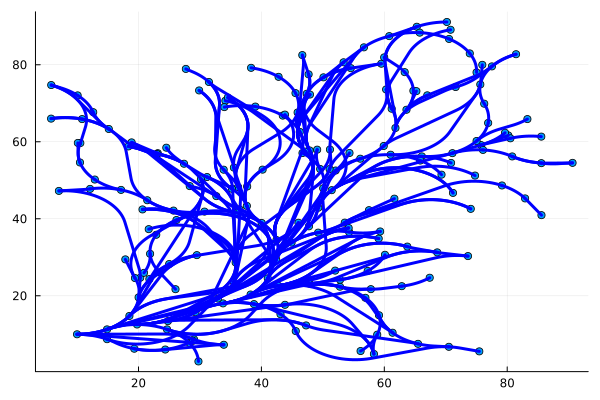

In [14]:
includet("plotting.jl")
using Plots

plot()
plot!(nodes, P.turning_radius;linewidth = 3,color=:blue, label=false, opacity=1)
plot!()